In [127]:
from dotenv import load_dotenv
load_dotenv()

True

In [128]:
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel, Field
from typing import Literal
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import interrupt,Command


In [129]:
class mailState(BaseModel):
    query : str = Field(description="user query", default="")
    draftMail : str = Field(description="ai response", default="")
    humanResponse : Literal["yes","no","approved"] = Field(default="no")
    finalMail : str = Field(description="final ai response after human approval",default="")


In [130]:
llm = ChatGroq(model="openai/gpt-oss-20b")

In [131]:
def draftMail_node(state:mailState)->mailState:
    prompt = """You are an expert email writing assistant.

Your task is to generate a complete, professional, and ready-to-send email from the user's request. Never ask follow-up questions or request additional information. If the user's prompt is brief or missing details, make reasonable assumptions and use generic placeholders only when absolutely necessary. Do not mention that information is missing.

Always:
- Generate an appropriate subject line.
- Use a suitable greeting.
- Write a clear, concise, and well-structured email body.
- End with a polite closing.
- Match the tone (formal, semi-formal, or friendly) based on the user's request.
- Return only the email without explanations, notes, or additional commentary.

If the recipient or sender is not specified, use generic greetings such as "Dear Sir/Madam", "Hello", or "Dear Team", and sign off with "Best regards" without a name. Ensure the email is grammatically correct, natural, and professional.
            user_query : {state.query} """
    response = llm.invoke(prompt)
    state.draftMail = response.content
    return state

In [132]:
def humanRes_node(state:mailState)->mailState:
    human = interrupt("Do you approve this Draft mail or want to change?")
    state.humanResponse = human
    return state


In [133]:
def route(state:mailState)->Literal["draftMail","sendMail"]:
    if state.humanResponse in ["yes","approved"]:
        return "sendMail"
    else:
        return "draftMail"


In [134]:
def sendMail_node(state:mailState)-> mailState :
    state.finalMail = state.draftMail
    print("mail sent successfully..")
    return state

In [135]:
graph = StateGraph(mailState)

# nodes
graph.add_node("draftMail",draftMail_node)
graph.add_node("human",humanRes_node)
graph.add_node("sendMail",sendMail_node)

# edges
graph.add_edge(START,"draftMail")
graph.add_edge("draftMail","human")
graph.add_conditional_edges("human",route)
graph.add_edge("sendMail",END)


memory = InMemorySaver()
graph = graph.compile(checkpointer=memory)

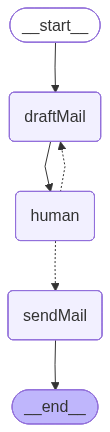

In [136]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

In [137]:
config = {"configurable":{"thread_id":"my-bot-1"}}
response = graph.invoke(
    {"query":"write an mail to hr for leave.reciepent = ramu , purpose = wedding , tone = formal"},
    config = config            
)
print(response["draftMail"])

Subject: Inquiry Regarding Partnership Opportunities  

Dear Sir/Madam,

I hope this message finds you well. I am writing to express interest in exploring potential collaboration opportunities between our organizations. We believe that a partnership could be mutually beneficial and would like to discuss how we can work together to achieve shared goals.

Could you please let me know a convenient time for a brief call or meeting? I am available next week and would be happy to accommodate your schedule.

Thank you for considering this proposal. I look forward to your response.

Best regards


In [138]:
user_input = input("\nEnter yes/no: ")

result = graph.invoke(
    Command(resume=user_input),
    config=config
)

print("\nFinal State:")
print(result)


Final State:
{'query': 'write an mail to hr for leave.reciepent = ramu , purpose = wedding , tone = formal', 'draftMail': 'Subject: Request for Information  \n\nDear Sir/Madam,\n\nI hope this message finds you well. I am writing to request additional information regarding the upcoming project timeline and deliverables. Could you please provide the latest schedule and any relevant documentation at your earliest convenience?\n\nThank you for your assistance. I look forward to your response.\n\nBest regards', 'humanResponse': 'no', 'finalMail': '', '__interrupt__': [Interrupt(value='Do you approve this Draft mail or want to change?', id='b81130b2284c8ee6435609e766e96a25')]}
